【Data Scaling(데이터 스케일링)】
- 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 피처 스케일링(feature scaling)이라고 한다.
- 피처(feature)=컬럼(column) 들마다 데이터의 값이 범위가 다 제각각이거나 단위가 다른 경우 데이터를 학습을 할때 0으로 수렴하거나 무한으로 발산할 수 있다.
  - 분석시에 변수들이 너무 스케일이 다를 경우  => 변수들의 단위 차이로 인해 숫자의 스케일이 크게 달라지는 경우
  - 신경망 학습시에 => 데이터셋의 값이 들쑥날쑥하거나, 매우 큰 경우에는 cost의 값이 발산하여 정상적인 학습이 이루어지지 않습니다.

- 이런 경우 데이터 스켈링을 통해 모든 피처들의 데이터 분포나 범위를 동일하게 조정해 줄 수 있다.
- Scaling 메서드는 scikit-learn의 preprocessing에서 제공한다.
- sklearn에서 제공하는 기본 Scaling 종류
   - StandardScaler : 평균이 0 분산이 1인 정규분포로 변환
   - MinMaxScaler :  0 ~ 1 사이의 실수로 변환, 타이타닉 생존자 예측(0 또는 1)과 같은 분류 문제보다는, 아파트 실거래가격 예측과 같은 회귀 문제를 해결할 때 더 적합한 스케일링 기법
   - RobustScaler : 중앙값이 0, 중앙값을 0으로, IQR을 1로 변환, StandardScaler에 비해 이상치의 영향이 적어진다는 장점
   - MaxAbsScaler : 모든 피처들의 절댓값이 0과 1 사이에 놓이도록 변환, 극단적인 이상치에는 민감할 수 있으므로 꼭 이상치를 제거
   - Normalizer :  row를 기준으로 row(data point)마다 정규화를 진행, 한 행의 모든 features 사이에 유클리드 거리가 1이 되도록 데이터값을 변환, Normalizer를 사용하면 학습 속도도 빨라지고 과대적합 확률을 낮춤

In [ ]:
# '파이썬 라이브러리를 활용한 머신러닝'의 저자가 제공한 라이브러리
# !uv add mglearn

Resolved 84 packages in 199ms                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)-------------------     0 B/310.55 KiB          
⠙ Preparing packages... (0/2)------------------- 16.00 KiB/310.55 KiB        
⠙ Preparing packages... (0/2)------------------- 32.00 KiB/310.55 KiB        
⠙ Preparing packages... (0/2)------------------- 48.00 KiB/310.55 KiB        
⠙ Preparing packages... (0/2)------------------- 63.74 KiB/310.55 KiB        
⠙ Preparing packages... (0/2)------------------- 79.74 KiB/310.55 KiB        
⠙ Preparing packages... (0/2)------------------- 95.74 KiB/310.55 KiB        
⠙ Preparing packages... (0/2)------------------- 111.74 KiB/310.55 KiB       
⠙ Preparing packages... (0/2)m------------------ 127.74 KiB/310.55 KiB       
⠙ Preparing packages... (0/2)m------------------ 127.74 KiB/310.55 KiB       
imageio              ------------------------------ 127.74 KiB/310.55

In [2]:
import mglearn

/Users/soohwi/sk-encoa/data-collection-workspace/.venv/lib/python3.12/site-packages/mglearn/datasets.py:37: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [3]:
print(dir(mglearn))

['ReBl', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'cm2', 'cm3', 'datasets', 'discrete_scatter', 'plot_2d_separator', 'plot_agglomerative', 'plot_animal_tree', 'plot_cross_validation', 'plot_dbscan', 'plot_decomposition', 'plot_grid_search', 'plot_helpers', 'plot_improper_preprocessing', 'plot_interactive_tree', 'plot_kmeans', 'plot_kneighbors_regularization', 'plot_knn_classification', 'plot_knn_regression', 'plot_linear_regression', 'plot_linear_svc_regularization', 'plot_metrics', 'plot_nmf', 'plot_nn_graphs', 'plot_pca', 'plot_rbf_svm_parameters', 'plot_ridge', 'plot_scaling', 'plot_tree_nonmonotonous', 'plots', 'tools']


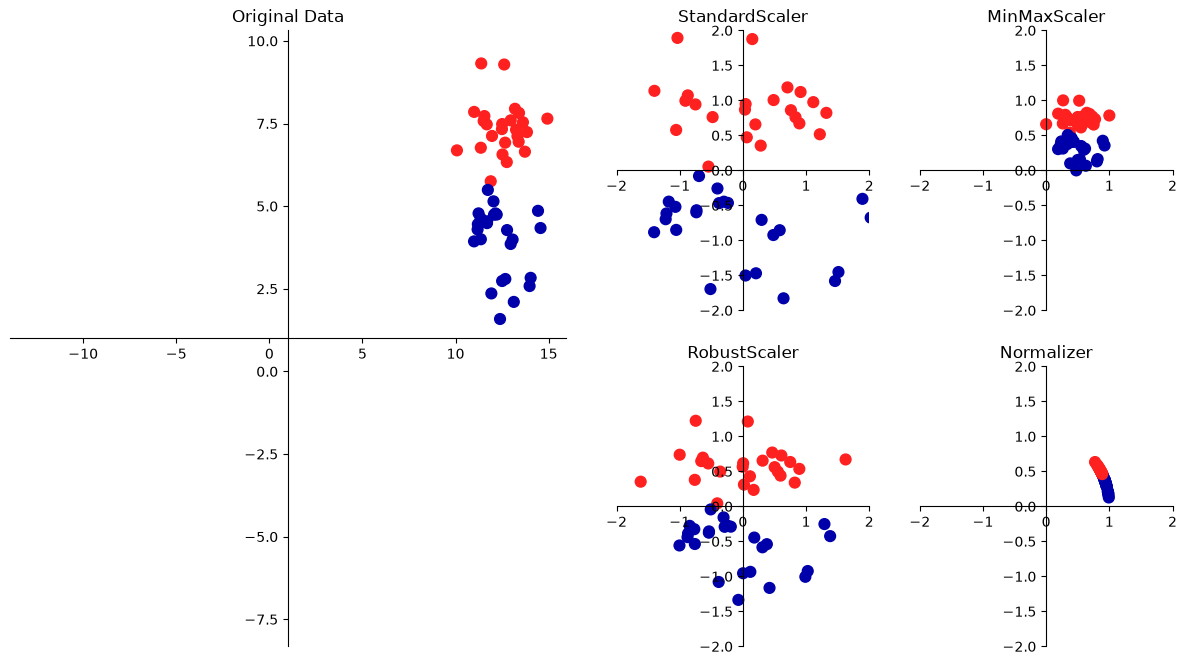

In [4]:
mglearn.plot_scaling.plot_scaling()

1. ## **`MaxAbsScaler`**

- 데이터의 **절대값이 1을 넘지 않도록** 스케일링
- 음수와 양수 값이 섞인 sparse 데이터에 적합
- 이상치에 민감하며, 분류보다는 회귀분석에서 유용


In [5]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform([[-1, 23], [0, 3], [1, -2]])
X_scaled


array([[-1.        ,  1.        ],
       [ 0.        ,  0.13043478],
       [ 1.        , -0.08695652]])

2. MinMaxScaler

- **최소-최대 정규화**: 데이터를 `[0, 1]` 범위로 변환
- 정규분포가 아닐때 사용
- 이상치에 민감
- 분류보다 회귀에 유용

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[0. , 0. ],
       [0.5, 0.5],
       [1. , 1. ]])

2.3 StandardScaler

- **Z-score 정규화**: 평균을 0, 표준편차를 1로 변환
- 이상치 영향을 받으므로 이상치가 없을때 사용
- 회귀보다는 분류분석에서 유용

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[-1.22474487, -1.22474487],
       [ 0.        ,  0.        ],
       [ 1.22474487,  1.22474487]])

2.4 Normalizer
- 각 행의 벡터 크기를 1로 정규화 (L1, L2, Max 노름 사용 가능)

In [8]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')
X_normalized = normalizer.transform([[1, 2], [3, 4]])
X_normalized


array([[0.4472136 , 0.89442719],
       [0.6       , 0.8       ]])

2.5 RobustScaler
- **중앙값과 IQR(사분위 범위) 기반 정규화**
- 이상치(Outlier)에 강한 정규화 방법

In [9]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 예제 데이터
data = {
    'Income': [3000, 3200, 3400, 100000, 3600],  # 이상치 존재
    'Age': [25, 26, 27, 28, 29]
}
df = pd.DataFrame(data)
print(" 원본 데이터:\n", df)

# RobustScaler 객체 생성 및 적용
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df)

# 결과를 DataFrame으로 변환
df_scaled = pd.DataFrame(scaled_data, columns=['Income_scaled', 'Age_scaled'])
print("RobustScaler 결과:\n", df_scaled)

# 3          241.5         0.5  이상이 영향 작음

 원본 데이터:
    Income  Age
0    3000   25
1    3200   26
2    3400   27
3  100000   28
4    3600   29
RobustScaler 결과:
    Income_scaled  Age_scaled
0           -1.0        -1.0
1           -0.5        -0.5
2            0.0         0.0
3          241.5         0.5
4            0.5         1.0


| Feature 이름          | 설명      | 단위 |
| ------------------- | ------- | -- |
| `sepal length (cm)` | 꽃받침의 길이 | cm |
| `sepal width (cm)`  | 꽃받침의 너비 | cm |
| `petal length (cm)` | 꽃잎의 길이  | cm |
| `petal width (cm)`  | 꽃잎의 너비  | cm |


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler

In [11]:
iris = load_iris()
print(dir(iris))
print(iris.target)

iris = pd.DataFrame(iris.data, columns=iris.feature_names)

iris['Class'] = load_iris().target
iris['Class'] = iris['Class'].map({0:'Setosa', 1:'Versicolour', 2:'Virginica'})
iris.head()

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
from sklearn.model_selection import train_test_split


# X_관측값_훈련, X_관측값_테스트, y_정답_훈련, y_정답_테스트
# stratify=iris['Class']: train, test을 분리할 때 값의 비율을 유지하면서 분리하도록 설정한 파라미터이다.
# stratify을 설정해 주지 않으면 target의 컬럼으로 자동 설정된다.
X_train, X_test, y_train, y_test = train_test_split(iris.drop(columns='Class'), iris['Class'], test_size=0.2, stratify=iris['Class']) #  test_size=0.25.

In [13]:
X_train.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
20,5.4,3.4,1.7,0.2
103,6.3,2.9,5.6,1.8
134,6.1,2.6,5.6,1.4
124,6.7,3.3,5.7,2.1
2,4.7,3.2,1.3,0.2


In [14]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(120, 4) (120,)
(30, 4) (30,)


In [15]:
print(y_train.value_counts())

Class
Setosa         44
Versicolour    41
Virginica      35
Name: count, dtype: int64


In [17]:
print(y_test.value_counts())

Class
Virginica      15
Versicolour     9
Setosa          6
Name: count, dtype: int64


In [20]:
import seaborn as sns

In [21]:
print(type(y_train))
print(y_train.head())

<class 'pandas.Series'>
52     Versicolour
141      Virginica
32          Setosa
12          Setosa
59     Versicolour
Name: Class, dtype: str


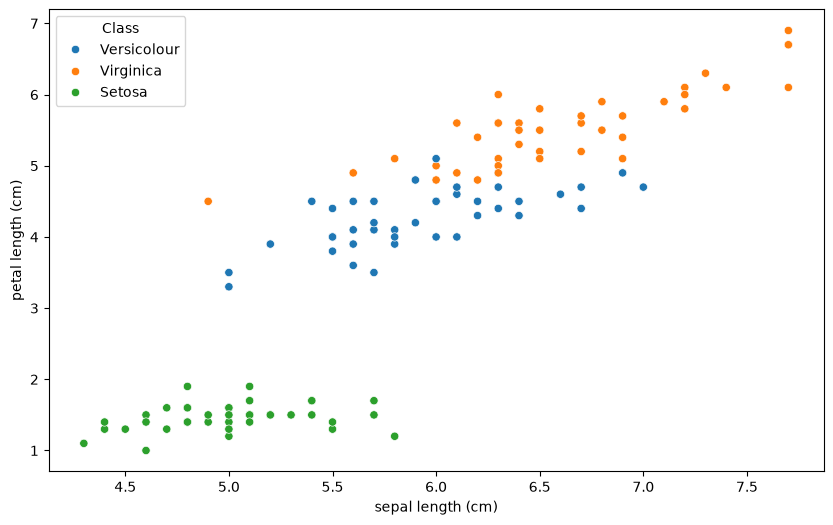

In [22]:
fig =sns.scatterplot(data=X_train, x=X_train.iloc[:,0], y=X_train.iloc[:,2], hue=y_train)
fig.figure.set_size_inches(10,6)

In [ ]:
# 중요 !!! 전처리 작업은 훈련데이터에서 배운 기준을 테스트 데이터에 그대로 적용해야 함. 각각 따로 fit 하면 안됨
# train만 fit, test는 transform만
StdScaler = StandardScaler()

# Train데이터의 fitting과 스케일링
StdScaler.fit(X_train)  #fit()은 학습을 시키는 메소드이다.
X_train_sc = StdScaler.transform(X_train)  #transform() 실제로 학습시킨 것을 적용하는 메소드이다.

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

		(min, max)  (mean,std)
Train_scaled (-2.44, 3.08) ( -0.00, 1.00)


In [24]:
StdScaler2 = StandardScaler()
StdScaler2.fit_transform(X_train)

array([[ 1.28224029,  0.09011988,  0.64761089,  0.3881439 ],
       [ 1.28224029,  0.09011988,  0.76181119,  1.44073751],
       [-0.79541673,  2.39105291, -1.29379427, -1.45389493],
       [-1.28427721, -0.13997343, -1.35089442, -1.45389493],
       [-0.79541673, -0.83025334,  0.07660937,  0.25656969],
       [ 1.64888565, -0.13997343,  1.16151225,  0.5197181 ],
       [ 0.54894958, -1.29043994,  0.64761089,  0.3881439 ],
       [-0.42877138,  1.01049309, -1.40799457, -1.32232073],
       [-1.77313768, -0.13997343, -1.40799457, -1.32232073],
       [-0.18434114,  1.700773  , -1.17959396, -1.19074653],
       [ 0.0600891 ,  0.32021318,  0.59051073,  0.7828665 ],
       [ 1.03781005,  0.09011988,  1.04731195,  1.57231171],
       [ 0.30451934, -0.60016003,  0.13370952,  0.12499549],
       [-1.03984697, -0.13997343, -1.23669412, -1.32232073],
       [-1.28427721,  0.78039979, -1.23669412, -1.32232073],
       [ 0.54894958, -0.37006673,  1.04731195,  0.7828665 ],
       [ 0.42673446, -1.

In [25]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,1.282240,1.282240,-0.795417,-1.284277,-0.795417,1.648886,0.548950,-0.428771,-1.773138,-0.184341,...,-0.428771,-0.428771,0.304519,-0.550986,-1.773138,-1.406492,0.793380,0.671165,0.426734,-1.039847
1,0.090120,0.090120,2.391053,-0.139973,-0.830253,-0.139973,-1.290440,1.010493,-0.139973,1.700773,...,-1.290440,-1.060347,-1.060347,1.930866,-0.370067,0.320213,-0.139973,0.090120,-0.600160,-1.750627
2,0.647611,0.761811,-1.293794,-1.350894,0.076609,1.161512,0.647611,-1.407995,-1.407995,-1.179594,...,0.133710,0.362110,1.047312,-1.179594,-1.350894,-1.236694,1.161512,0.990212,0.590511,-0.265992
3,0.388144,1.440738,-1.453895,-1.453895,0.256570,0.519718,0.388144,-1.322321,-1.322321,-1.190747,...,0.124995,-0.006579,0.256570,-1.059172,-1.322321,-1.322321,1.309163,0.782867,0.782867,-0.269727


In [27]:
xt.shape

(4, 120)

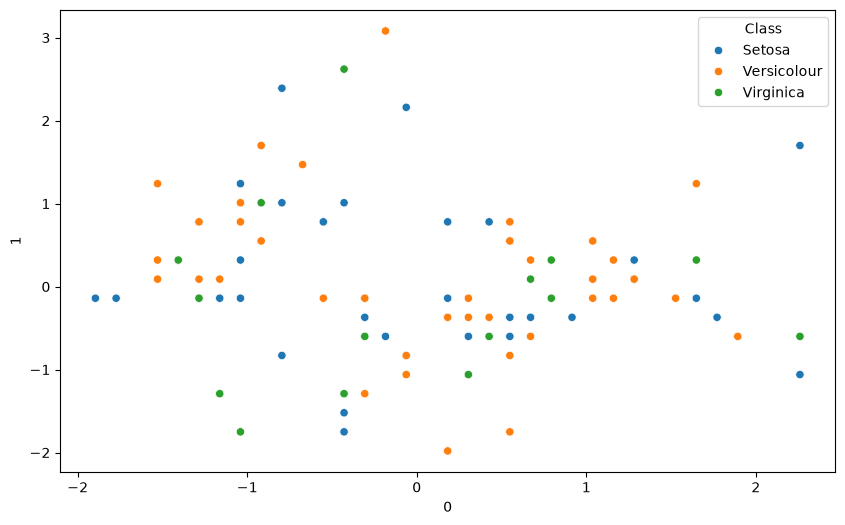

In [28]:
fig =sns.scatterplot(data=xt, x=xt.iloc[0,:], y=xt.iloc[1,], hue=y_train)
fig.figure.set_size_inches(10,6)

In [29]:
from sklearn.preprocessing import MinMaxScaler

MmScaler = MinMaxScaler()

# Train 데이터의 fitting과 스케일링
# fit()은 학습을 시키는 메소드이다.
MmScaler.fit(X_train)

#transform()은 실제로 학습시킨 것을 적용하는 메소드이다.
X_train_sc = MmScaler.transform(X_train)
print(X_train_sc.shape)

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

(120, 4)
		(min, max)  (mean,std)
Train_scaled (0.00, 1.00) ( 0.46, 0.26)


(480,)


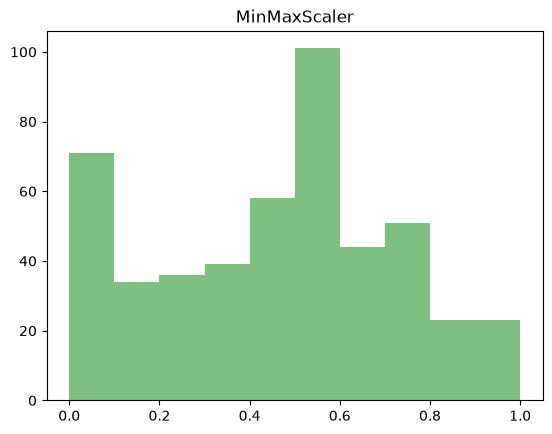

In [30]:
X_train_sc_flat = X_train_sc.flatten()
print(X_train_sc_flat.shape)
#print(X_train_sc_flat)
plt.hist(X_train_sc_flat, color='green', alpha=0.5)
plt.title('MinMaxScaler')
plt.show()

In [31]:
xt = pd.DataFrame(X_train_sc).T

In [32]:
xt.iloc[0, :].shape

(120,)

In [33]:
xt.iloc[1, :].shape

(120,)

In [34]:
xt.shape

(4, 120)

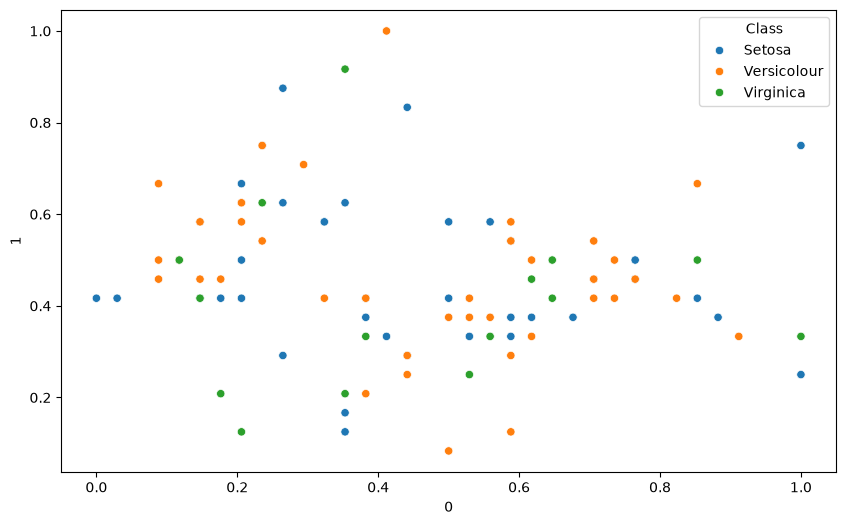

In [35]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [36]:
from sklearn.preprocessing import MaxAbsScaler

MaScaler = MaxAbsScaler()

# Train 데이터의 fitting과 스케일링
MaScaler.fit(X_train)
X_train_sc = MaScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (0.04, 1.00) (0.62, 0.24)


In [37]:
X_train_sc.shape

(120, 4)

In [38]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.896104,0.896104,0.675325,0.623377,0.675325,0.935065,0.818182,0.714286,0.571429,0.740260,...,0.714286,0.714286,0.792208,0.701299,0.571429,0.610390,0.844156,0.831169,0.805195,0.649351
1,0.704545,0.704545,0.931818,0.681818,0.613636,0.681818,0.568182,0.795455,0.681818,0.863636,...,0.568182,0.590909,0.590909,0.886364,0.659091,0.727273,0.681818,0.704545,0.636364,0.522727
2,0.710145,0.739130,0.217391,0.202899,0.565217,0.840580,0.710145,0.188406,0.188406,0.246377,...,0.579710,0.637681,0.811594,0.246377,0.202899,0.231884,0.840580,0.797101,0.695652,0.478261
3,0.600000,0.920000,0.040000,0.040000,0.560000,0.640000,0.600000,0.080000,0.080000,0.120000,...,0.520000,0.480000,0.560000,0.160000,0.080000,0.080000,0.880000,0.720000,0.720000,0.400000


In [39]:
xt.shape

(4, 120)

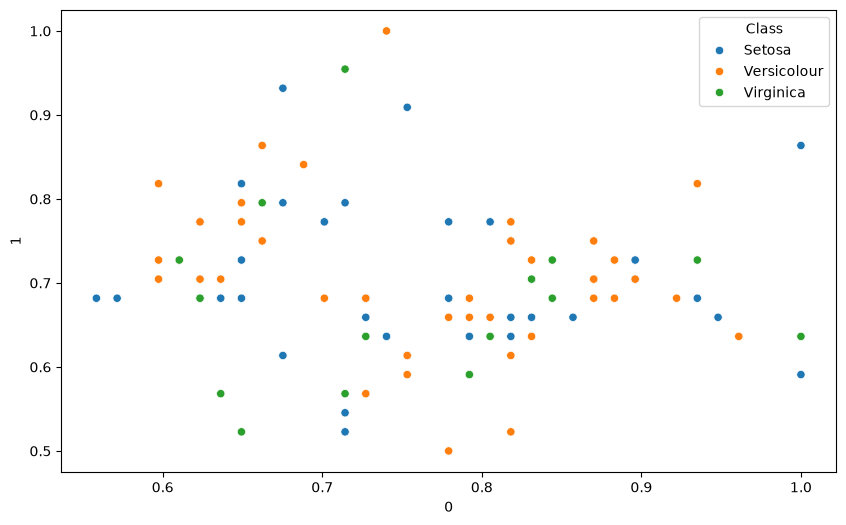

In [40]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [ ]:
from sklearn.preprocessing import RobustScaler

RuScaler = RobustScaler()

# Train 데이터의 fitting과 스케일링
RuScaler.fit(X_train)
X_train_sc = RuScaler.transform(X_train)

print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (-1.88, 3.29) (-0.05, 0.70)


In [ ]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.326531,-0.734694,0.081633,-0.571429,0.489796,0.653061,0.000000,0.163265,-0.571429,0.653061,...,-0.163265,-0.081633,-0.979592,-0.408163,-0.081633,0.489796,-0.571429,-0.816327,0.408163,-0.163265
1,-0.235294,0.235294,0.470588,0.941176,0.470588,0.000000,-0.705882,0.941176,1.176471,-0.235294,...,-0.705882,0.000000,0.941176,1.647059,-0.470588,0.235294,1.882353,0.000000,-0.235294,-1.176471
2,-0.057143,-0.857143,0.085714,-0.857143,0.000000,-0.028571,0.171429,0.000000,-0.885714,0.028571,...,-0.085714,-0.085714,-0.885714,-0.857143,0.000000,0.285714,-0.857143,-0.885714,0.314286,-0.171429
3,-0.071429,-0.857143,0.285714,-0.857143,0.071429,0.000000,0.357143,0.142857,-0.785714,-0.071429,...,-0.071429,-0.142857,-0.785714,-0.857143,-0.071429,0.285714,-0.785714,-0.785714,0.285714,-0.214286


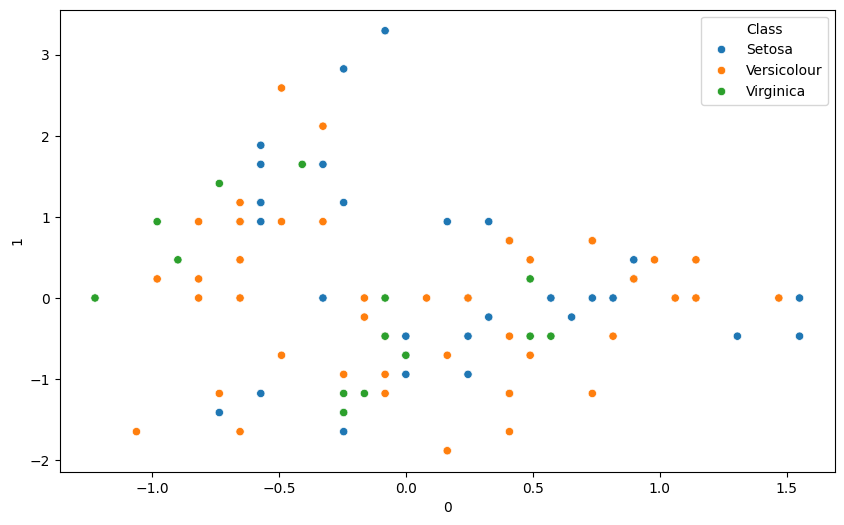

In [ ]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [ ]:
from sklearn.preprocessing import Normalizer

NoScaler = Normalizer()


# Train 데이터의 fitting과 스케일링
NoScaler.fit(X_train)
X_train_sc = NoScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))


		(min, max) (mean, std)
Train_scaled (0.01, 0.86) (0.44, 0.24)


In [ ]:
xt = pd.DataFrame(X_train_sc.T)

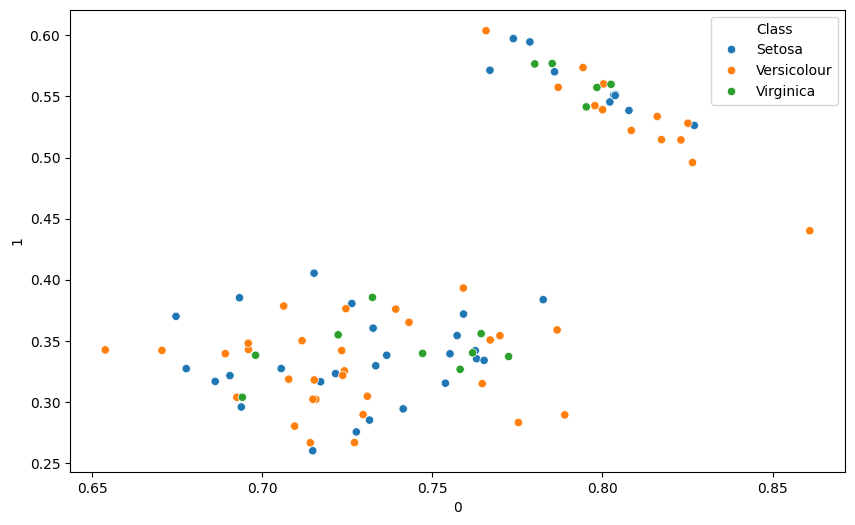

In [ ]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)